<a href="https://colab.research.google.com/github/NikitaIvagin/ml-portfolio/blob/main/computer_vision/traffic_sign_detection/Traffic_sign_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ultralytics --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 36.7 MB/s eta 0:00:00


In [ ]:
import ultralytics

from ultralytics import YOLO
import os
from PIL import Image
import cv2
from IPython.display import Video
import glob
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')


ultralytics.checks()

Ultralytics 8.4.42 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 42.9/112.6 GB disk)


In [ ]:
!wget https://storage.yandexcloud.net/academy.ai/CV/traffic_signs_detection.zip

--2026-04-27 17:17:34--  https://storage.yandexcloud.net/academy.ai/CV/traffic_signs_detection.zip
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 104699644 (100M) [application/x-zip-compressed]
Saving to: ‘traffic_signs_detection.zip’

traffic_signs_detec 100%[===================>]  99.85M  15.5MB/s    in 8.4s    

2026-04-27 17:17:44 (11.8 MB/s) - ‘traffic_signs_detection.zip’ saved [104699644/104699644]



In [ ]:
!unzip -qo "traffic_signs_detection.zip"

In [ ]:
import os
yaml_path = './car/data.yaml'

In [ ]:
model = YOLO('yolo11s.pt')

In [ ]:
results = model.train(
    data=yaml_path,
    epochs=15,
    batch=32,
    imgsz=640,
    plots= True,
    project='car_detection',
    name='train_yolov11_car_signs'
)

Используемый YAML-файл для датасета: ./car/data.yaml
Файл датасета найден. Запускаю тренировку модели...
Ultralytics 8.4.42 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./car/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train_yolov

In [ ]:
def result_train(path):
    img = cv2.imread(path)
    plt.figure(figsize=(10,10), dpi= 200)
    plt.imshow(img)

In [ ]:
import random
test_dir = "./car/test/images"
img_dir = os.path.join(test_dir, '*.jpg')
files = glob.glob(img_dir)


image 1/1 /content/car/test/images/FisheyeCamera_1_00041_png.rf.402d963ad90df5846463e66a301debd3.jpg: 640x640 1 Green Light, 10.6ms
Speed: 3.4ms preprocess, 10.6ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


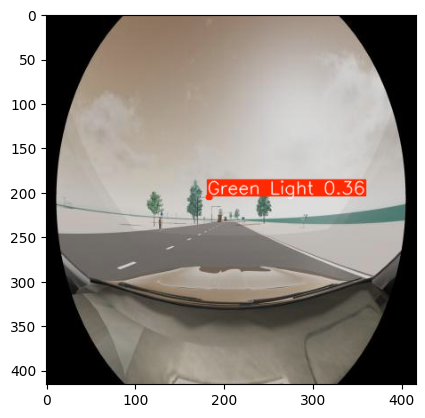

In [ ]:
image_test_path = random.choice(files)

pred = model.predict(source=image_test_path, imgsz=640)

test_image = pred[0].plot(line_width=2)
plt.imshow(test_image)

In [ ]:
example_video_path = './video.mp4'

video_output = model.predict(source=example_video_path, conf=0.6, save=True, project='car_detection', name='video_inference')


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/508) /content/video.mp4: 640x640 1 Stop, 17.2ms
video 1/1 (frame 2/508) /content/video.mp4: 640x640 1 Stop, 10.5ms
video 1/1 (frame 3/508) /content/video.mp4: 640x640 1 Stop, 10.5ms
video 1/1 (frame 4/508) /content/video.mp4: 640x640 (no detections), 10.6ms
video 1/1 (frame 5/508) /content/video.mp4: 640x640 1 Stop, 10.5ms
video 1/1 (frame 6/508) /content/video.mp4: 640x640 1 Stop, 10.5ms
video 1/1 (frame 7/508) /content/video.mp4: 640

In [ ]:
# Хоть видео и не является плавным, на стоп-кадрах можно увидеть, что модель верно опознает целевые объекты, хоть и не всегда с высокой степенью уверенности
from moviepy.editor import *

path="./runs/detect/car_detection/video_inference/video.avi"

clip=VideoFileClip(path)
clip.ipython_display(width=960)

Moviepy - Building video __temp__.mp4.
Moviepy - Writing video __temp__.mp4



Moviepy - Done !
Moviepy - video ready __temp__.mp4
